# K-Nearest Neighbors -- UCI Dry Bean Dataset

This notebook demonstrates K-Nearest Neighbors classification on the UCI Dry Bean dataset,
where each sample is described by 16 morphological features extracted from a photograph of a
single bean grain. The target is the variety: one of seven Turkish bean cultivars.

- Train a KNN classifier and evaluate it with a confusion matrix
- Choose k by plotting accuracy vs. number of neighbors
- Compare Euclidean vs. Manhattan distance and uniform vs. distance weighting
- Visualise the 5 nearest neighbors for a query sample in 2-D PCA space

## Mathematical Intuition

**K-Nearest Neighbors** makes a prediction for a query point $\mathbf{x}$ by finding the $k$
training points closest to $\mathbf{x}$ under a chosen distance metric, then taking a majority
vote.

**Euclidean distance** between points $\mathbf{a}$ and $\mathbf{b}$ in $\mathbb{R}^d$:

$$d_{\text{Euclidean}}(\mathbf{a}, \mathbf{b}) = \sqrt{\sum_{j=1}^{d} (a_j - b_j)^2}$$

**Manhattan distance:**

$$d_{\text{Manhattan}}(\mathbf{a}, \mathbf{b}) = \sum_{j=1}^{d} |a_j - b_j|$$

**Majority vote** (uniform weights): $\hat{y} = \arg\max_c \sum_{i \in N_k} \mathbf{1}[y_i = c]$

## Dataset Overview

**Source:** UCI Dry Bean (`fetch_ucirepo(id=602)`) | **Rows:** 13,611 | **Features:** 16
morphological measurements (area, perimeter, axis lengths, shape factors) | **Target:**
bean variety (7 classes: BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ, SEKER, SIRA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from ucimlrepo import fetch_ucirepo
from mlpackage import (
    KNNClassifier, PCA,
    StandardScaler, train_test_split,
    confusion_matrix,
)

bean = fetch_ucirepo(id=602)
X_df = bean.data.features
y_str = bean.data.targets.iloc[:, 0].values

classes_sorted = sorted(set(y_str))
class_to_int   = {c: i for i, c in enumerate(classes_sorted)}
int_to_class   = {i: c for c, i in class_to_int.items()}
y_raw = np.array([class_to_int[c] for c in y_str])
X_raw = X_df.values.astype(float)
feature_names = list(X_df.columns)

print(f"Shape  : {X_raw.shape}")
print(f"Classes: {classes_sorted}")
print(f"Counts : {dict(zip(*np.unique(y_str, return_counts=True)))}")

Shape  : (13611, 16)
Classes: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
Counts : {'BARBUNYA': np.int64(1322), 'BOMBAY': np.int64(522), 'CALI': np.int64(1630), 'DERMASON': np.int64(3546), 'HOROZ': np.int64(1928), 'SEKER': np.int64(2027), 'SIRA': np.int64(2636)}


## Exploratory Data Analysis

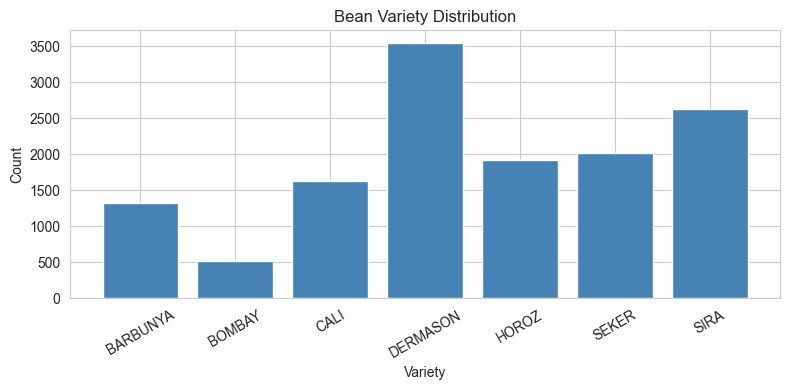

In [2]:
counts = pd.Series(y_str).value_counts().reindex(classes_sorted)

plt.figure(figsize=(8, 4))
plt.bar(classes_sorted, counts.values, color="steelblue")
plt.title("Bean Variety Distribution")
plt.xlabel("Variety")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

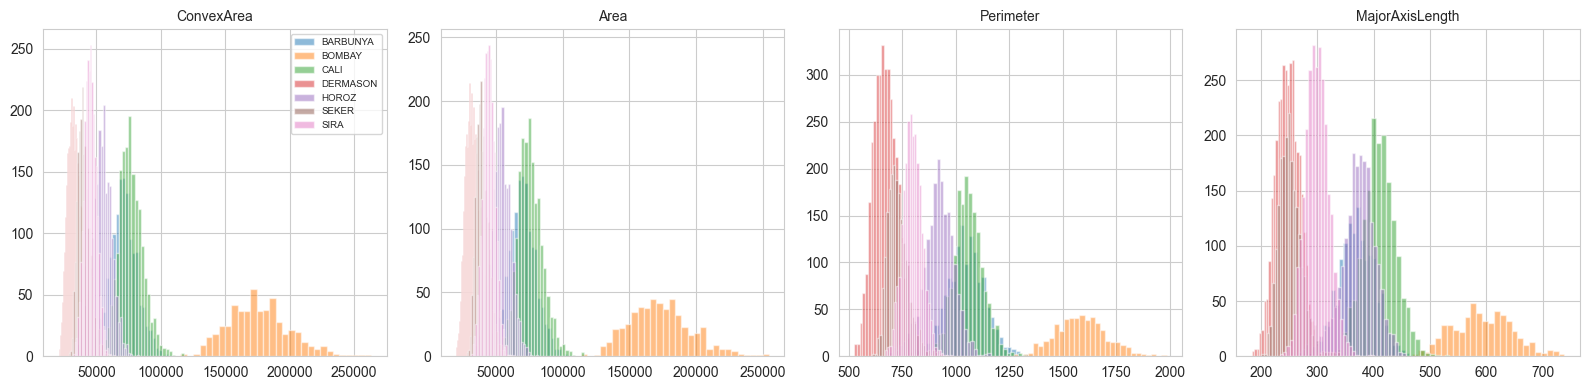

In [3]:
# Per-feature distributions, coloured by class for the 4 most variable features
top4 = np.argsort(X_raw.var(axis=0))[::-1][:4]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cmap = plt.get_cmap("tab10")
for ax, fi in zip(axes, top4):
    for cls_i in range(len(classes_sorted)):
        vals = X_raw[y_raw == cls_i, fi]
        ax.hist(vals, bins=30, alpha=0.5, color=cmap(cls_i),
                label=int_to_class[cls_i])
    ax.set_title(feature_names[fi], fontsize=10)
    if fi == top4[0]:
        ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## Preprocessing

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train size: {X_train_s.shape[0]}  |  Test size: {X_test_s.shape[0]}")

Train size: 10888  |  Test size: 2723


## Default KNN (k=5, Euclidean, uniform weights)

In [5]:
knn = KNNClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)

train_acc = knn.score(X_train_s, y_train)
test_acc  = knn.score(X_test_s, y_test)
print(f"Train accuracy: {train_acc:.4f}  |  Test accuracy: {test_acc:.4f}")

Train accuracy: 0.9416  |  Test accuracy: 0.9203


k= 1  Train: 1.0000  |  Test: 0.9053
k= 3  Train: 0.9521  |  Test: 0.9170
k= 5  Train: 0.9416  |  Test: 0.9203
k= 7  Train: 0.9367  |  Test: 0.9221
k=10  Train: 0.9338  |  Test: 0.9291
k=15  Train: 0.9321  |  Test: 0.9251
k=20  Train: 0.9295  |  Test: 0.9258
k=30  Train: 0.9270  |  Test: 0.9221

Best test accuracy at k=10: 0.9291


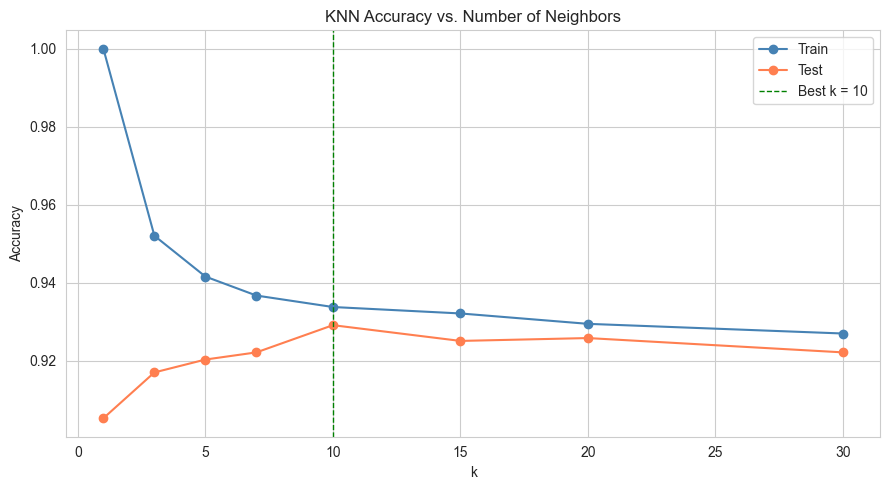

In [6]:
# Sweep over k
ks = [1, 3, 5, 7, 10, 15, 20, 30]
train_accs, test_accs = [], []

for k in ks:
    m = KNNClassifier(n_neighbors=k).fit(X_train_s, y_train)
    train_accs.append(m.score(X_train_s, y_train))
    test_accs.append(m.score(X_test_s, y_test))
    print(f"k={k:2d}  Train: {train_accs[-1]:.4f}  |  Test: {test_accs[-1]:.4f}")

best_k = ks[int(np.argmax(test_accs))]
print(f"\nBest test accuracy at k={best_k}: {max(test_accs):.4f}")

plt.figure(figsize=(9, 5))
plt.plot(ks, train_accs, marker="o", label="Train", color="steelblue")
plt.plot(ks, test_accs,  marker="o", label="Test",  color="coral")
plt.axvline(best_k, color="green", linestyle="--", linewidth=1, label=f"Best k = {best_k}")
plt.title("KNN Accuracy vs. Number of Neighbors")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

metric=euclidean  Train: 0.9338  |  Test: 0.9291
metric=manhattan  Train: 0.9319  |  Test: 0.9218


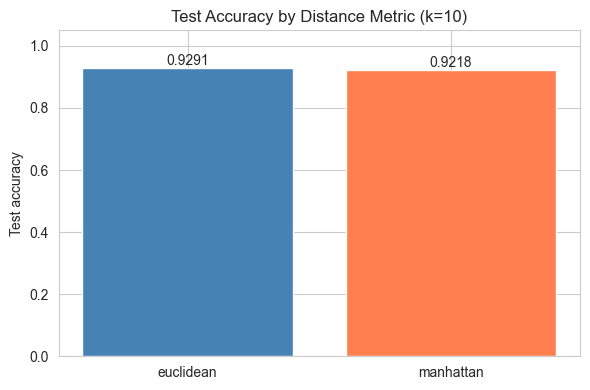

In [7]:
# Distance metric comparison at best k
results_metric = {}
for metric in ["euclidean", "manhattan"]:
    m = KNNClassifier(n_neighbors=best_k, metric=metric).fit(X_train_s, y_train)
    tr = m.score(X_train_s, y_train)
    te = m.score(X_test_s,  y_test)
    results_metric[metric] = (tr, te)
    print(f"metric={metric:10s} Train: {tr:.4f}  |  Test: {te:.4f}")

plt.figure(figsize=(6, 4))
metrics = list(results_metric.keys())
test_scores = [results_metric[m][1] for m in metrics]
plt.bar(metrics, test_scores, color=["steelblue", "coral"])
plt.title(f"Test Accuracy by Distance Metric (k={best_k})")
plt.ylabel("Test accuracy")
plt.ylim(0.0, 1.05)
for i, v in enumerate(test_scores):
    plt.text(i, v + 0.01, f"{v:.4f}", ha="center")
plt.tight_layout()
plt.show()

weights=uniform   Train: 0.9338  |  Test: 0.9291
weights=distance  Train: 1.0000  |  Test: 0.9266


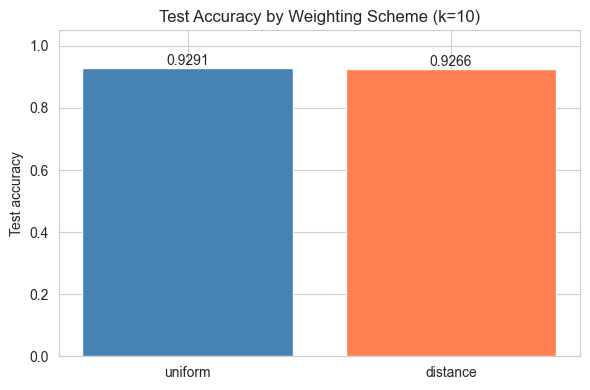

In [8]:
# Weighting scheme comparison at best k
results_w = {}
for w in ["uniform", "distance"]:
    m = KNNClassifier(n_neighbors=best_k, weights=w).fit(X_train_s, y_train)
    tr = m.score(X_train_s, y_train)
    te = m.score(X_test_s,  y_test)
    results_w[w] = (tr, te)
    print(f"weights={w:9s} Train: {tr:.4f}  |  Test: {te:.4f}")

plt.figure(figsize=(6, 4))
ws = list(results_w.keys())
test_scores = [results_w[w][1] for w in ws]
plt.bar(ws, test_scores, color=["steelblue", "coral"])
plt.title(f"Test Accuracy by Weighting Scheme (k={best_k})")
plt.ylabel("Test accuracy")
plt.ylim(0.0, 1.05)
for i, v in enumerate(test_scores):
    plt.text(i, v + 0.01, f"{v:.4f}", ha="center")
plt.tight_layout()
plt.show()

## Visualizations

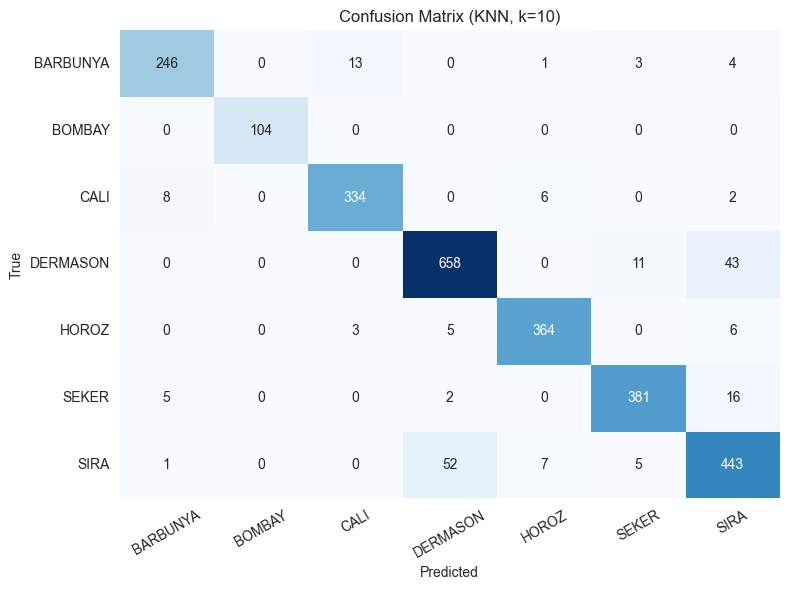

Test accuracy: 0.9291


In [9]:
best = KNNClassifier(n_neighbors=best_k).fit(X_train_s, y_train)
y_pred = best.predict(X_test_s)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes_sorted, yticklabels=classes_sorted, cbar=False)
plt.title(f"Confusion Matrix (KNN, k={best_k})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Test accuracy: {best.score(X_test_s, y_test):.4f}")

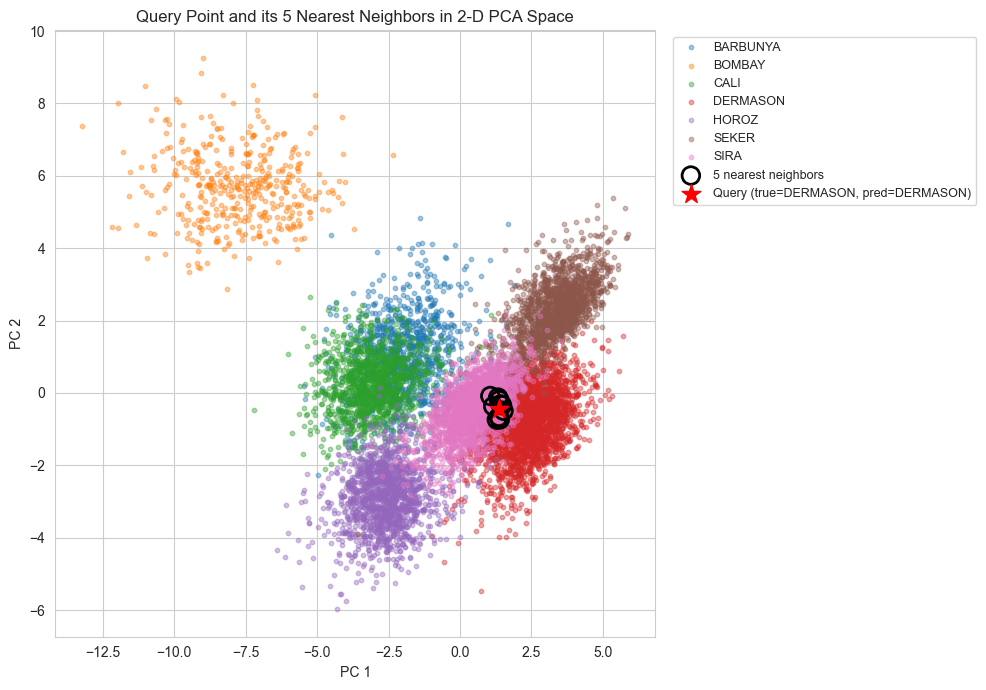

In [10]:
# Project to 2-D PCA, pick a query point, and highlight its 5 nearest neighbors
pca2 = PCA(n_components=2)
pca2.fit(X_train_s)
Z_train = pca2.transform(X_train_s)
Z_test  = pca2.transform(X_test_s)

query_idx = 0
query     = X_test_s[query_idx:query_idx+1]
dists, nbr_idx = best.kneighbors(query)
nbr_idx = nbr_idx[0]
true_label = int(y_test[query_idx])
pred_label = int(best.predict(query)[0])

cmap = plt.get_cmap("tab10")
plt.figure(figsize=(10, 7))
for cls_i in range(len(classes_sorted)):
    m = y_train == cls_i
    plt.scatter(Z_train[m, 0], Z_train[m, 1], color=cmap(cls_i), s=10,
                alpha=0.4, label=int_to_class[cls_i])
plt.scatter(Z_train[nbr_idx, 0], Z_train[nbr_idx, 1],
            facecolors="none", edgecolors="black", s=160, linewidths=2,
            label="5 nearest neighbors")
plt.scatter(Z_test[query_idx, 0], Z_test[query_idx, 1],
            color="red", s=200, marker="*",
            label=f"Query (true={int_to_class[true_label]}, pred={int_to_class[pred_label]})")
plt.title("Query Point and its 5 Nearest Neighbors in 2-D PCA Space")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

In [11]:
# Per-class accuracy on the held-out test set
print(f"{'Variety':<12s}  {'Accuracy':>9s}  {'Support':>8s}")
print("-" * 36)
for cls_i in range(len(classes_sorted)):
    mask = y_test == cls_i
    n    = int(mask.sum())
    if n > 0:
        acc = float((y_pred[mask] == cls_i).mean())
        print(f"{int_to_class[cls_i]:<12s}  {acc:>9.4f}  {n:>8d}")

Variety        Accuracy   Support
------------------------------------
BARBUNYA         0.9213       267
BOMBAY           1.0000       104
CALI             0.9543       350
DERMASON         0.9242       712
HOROZ            0.9630       378
SEKER            0.9431       404
SIRA             0.8720       508


## Interpretation and Conclusions

_Analysis to be completed after running the notebook end-to-end._